# Proyek Data Science End-to-End: Prediksi Churn Pelanggan

Notebook ini mencakup: problem statement, business understanding, data collection, preprocessing, EDA, feature engineering, model building, model evaluation, dan deployment.

## 1. Problem Statement & Business Understanding

Pelanggan churn menyebabkan kehilangan pendapatan. Kami akan memprediksi apakah seorang pelanggan akan churn berdasarkan karakteristik akun dan riwayat transaksi.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 2. Data Collection

Untuk demonstrasi, kita buat dataset sintetis yang mewakili data pelanggan e-commerce.

In [2]:
def create_synthetic_churn_data(n_samples=2000, random_state=42):
    rng = np.random.RandomState(random_state)
    data = {
        'customer_age': rng.randint(18, 70, size=n_samples),
        'account_balance': rng.normal(50000, 20000, size=n_samples).clip(0),
        'tenure_months': rng.randint(1, 60, size=n_samples),
        'total_transactions': rng.poisson(15, size=n_samples).clip(0),
        'is_premium': rng.choice(['yes', 'no'], size=n_samples, p=[0.3, 0.7]),
        'support_tickets': rng.poisson(2, size=n_samples),
        'avg_order_value': rng.normal(150, 80, size=n_samples).clip(10),
    }
    df = pd.DataFrame(data)
    score = (df['support_tickets'] * 0.35 +
             (df['account_balance'] < 20000).astype(float) * 0.25 +
             (df['tenure_months'] < 12).astype(float) * 0.25 +
             (df['is_premium'] == 'no').astype(float) * 0.15 +
             rng.randn(n_samples) * 0.1)
    churn = (score > 0.7).astype(int)
    df['churn'] = churn
    return df

raw_df = create_synthetic_churn_data()
raw_df.head()

,customer_age,account_balance,tenure_months,total_transactions,is_premium,support_tickets,avg_order_value,churn
0,56,37000.535763,21,17,no,3,89.199698,1
1,69,68744.472431,28,15,no,1,10.000000,0
2,46,46767.485091,35,19,yes,0,187.714360,0
3,32,23174.506580,22,16,no,4,78.973164,1
4,60,21477.489347,40,22,no,3,92.719471,1


## 3. Data Preprocessing

Kita membersihkan, mengisi nilai hilang, dan menyiapkan fitur untuk model.

In [3]:
df = raw_df.copy()
df['avg_order_value'] = df['avg_order_value'].round(2)
df['support_tickets'] = df['support_tickets'].clip(0, 10)
df.loc[df.sample(frac=0.01, random_state=42).index, 'account_balance'] = np.nan
df.loc[df.sample(frac=0.01, random_state=52).index, 'is_premium'] = np.nan

df['account_balance'].fillna(df['account_balance'].median(), inplace=True)
df['is_premium'].fillna('no', inplace=True)

df.isna().sum()

C:\Users\perpustakaan1\AppData\Local\Temp\ipykernel_20692\90849510.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['account_balance'].fillna(df['account_balance'].median(), inplace=True)
C:\Users\perpustakaan1\AppData\Local\Temp\ipykernel_20692\90849510.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

customer_age          0
account_balance       0
tenure_months         0
total_transactions    0
is_premium            0
support_tickets       0
avg_order_value       0
churn                 0
dtype: int64

## 4. Exploratory Data Analysis

Visualisasi distribusi fitur dan hubungan dengan churn.

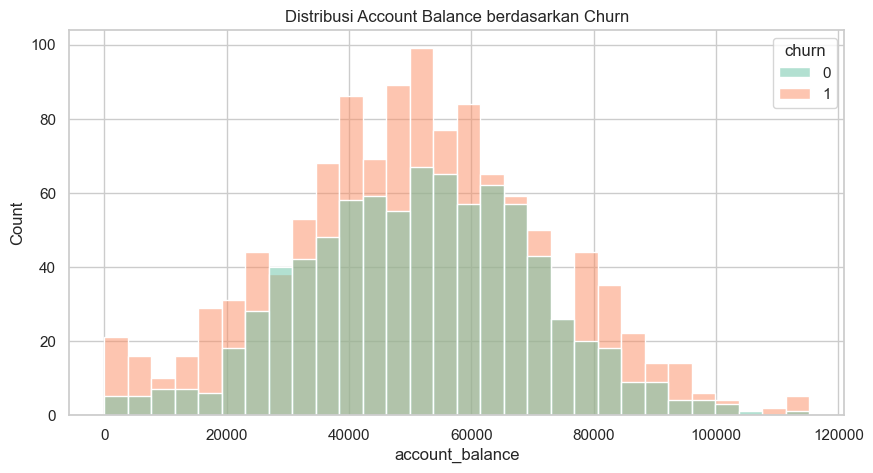

C:\Users\perpustakaan1\AppData\Local\Temp\ipykernel_20692\2945009001.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set3')


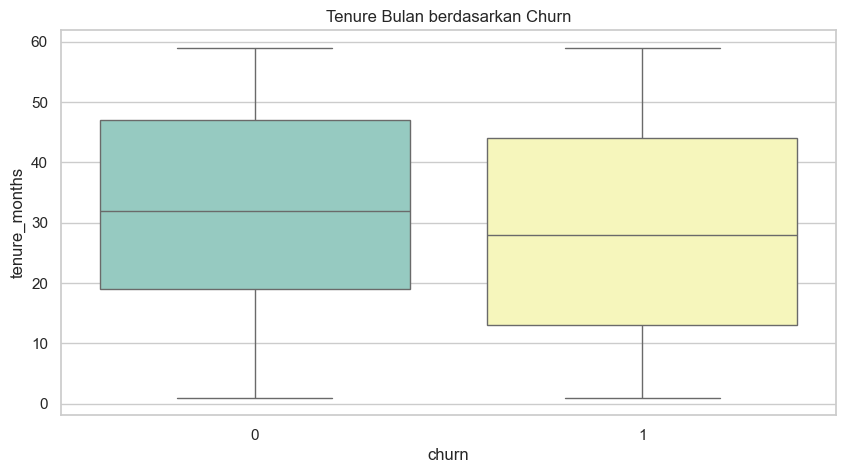

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(df, x='account_balance', hue='churn', bins=30, kde=False, palette='Set2')
plt.title('Distribusi Account Balance berdasarkan Churn')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='churn', y='tenure_months', data=df, palette='Set3')
plt.title('Tenure Bulan berdasarkan Churn')
plt.show()

## 5. Feature Engineering

Buat fitur baru yang memberi sinyal churn.

In [5]:
df['transactions_per_month'] = df['total_transactions'] / df['tenure_months'].replace(0, 1)
df['avg_balance_per_month'] = df['account_balance'] / df['tenure_months'].replace(0, 1)
df['ticket_per_transaction'] = df['support_tickets'] / df['total_transactions'].replace(0, 1)
df['is_premium_flag'] = (df['is_premium'] == 'yes').astype(int)
df[['transactions_per_month', 'avg_balance_per_month', 'ticket_per_transaction', 'is_premium_flag']].head()

,transactions_per_month,avg_balance_per_month,ticket_per_transaction,is_premium_flag
0,0.809524,1761.930274,0.176471,0
1,0.535714,2455.159730,0.066667,0
2,0.542857,1336.213860,0.000000,1
3,0.727273,1053.386663,0.250000,0
4,0.550000,536.937234,0.136364,0


## 6. Model Building

Gunakan pipeline scikit-learn dengan preprocessing dan model Random Forest.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = [
    'customer_age',
    'account_balance',
    'tenure_months',
    'total_transactions',
    'avg_order_value',
    'transactions_per_month',
    'avg_balance_per_month',
    'ticket_per_transaction',
]
categorical_features = ['is_premium']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=200, random_state=42)),
])

X = df[numeric_features + categorical_features]
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline.fit(X_train, y_train)

TypeError: OneHotEncoder.__init__() got an unexpected keyword argument 'sparse'

## 7. Model Evaluation

Evaluasi model menggunakan metrik klasifikasi dan ROC AUC.

In [ ]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

## 8. Save Model untuk Deployment

Simpan model terlatih untuk digunakan di aplikasi Streamlit.

In [ ]:
import joblib
from pathlib import Path

model_path = Path('..') / 'models' / 'customer_churn_model.joblib'
model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(pipeline, model_path)
print(f'Berhasil menyimpan model ke {model_path}')